In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

## Types of Time Series Data

![](https://miro.medium.com/max/1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg)

reference: https://engineering.99x.io/time-series-forecasting-in-machine-learning-3972f7a7a467

In [2]:
df = pd.read_csv('/kaggle/input/datasets/adelk8120/pjme-hourly-dataset/PJME_hourly.csv')
df.head(3)

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0


In [3]:
df['rolling_mean_24'] = df['PJME_MW'].rolling(24).mean()
df['rolling_std_24'] = df['PJME_MW'].rolling(24).std()

In [4]:
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

In [5]:
df.head()

,PJME_MW,rolling_mean_24,rolling_std_24
Datetime,,,
2002-12-31 01:00:00,26498.0,NaN,NaN
2002-12-31 02:00:00,25147.0,NaN,NaN
2002-12-31 03:00:00,24574.0,NaN,NaN
2002-12-31 04:00:00,24393.0,NaN,NaN
2002-12-31 05:00:00,24860.0,NaN,NaN


In [6]:
df.tail()

,PJME_MW,rolling_mean_24,rolling_std_24
Datetime,,,
2018-01-01 20:00:00,44284.0,40343.500000,2295.270146
2018-01-01 21:00:00,43751.0,40282.750000,2177.148998
2018-01-01 22:00:00,42402.0,40230.208333,2106.081917
2018-01-01 23:00:00,40164.0,40171.166667,2086.336995
2018-01-02 00:00:00,38608.0,40136.041667,2105.992351


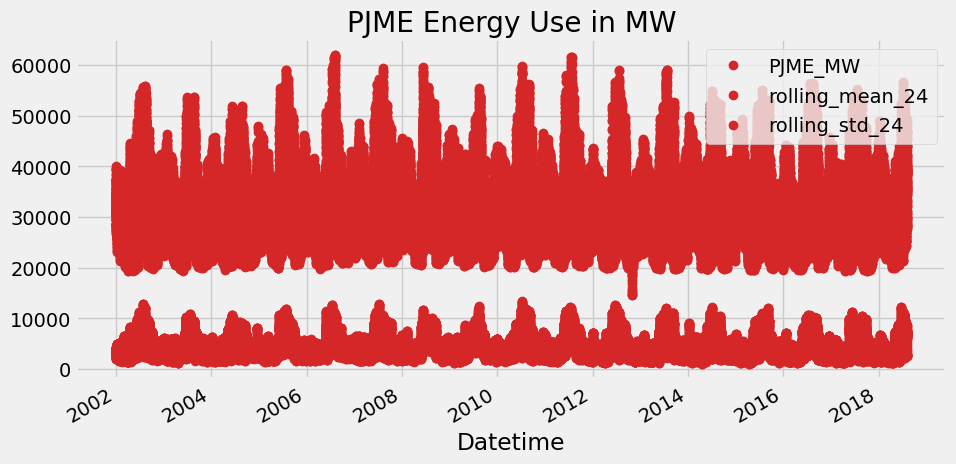

In [7]:
df.plot(style='o',
        figsize=(10, 5),
        color=color_pal[3],
        title='PJME Energy Use in MW')
plt.show()

# Outlier handlingOutlier Analysis and removal

<Axes: ylabel='Frequency'>

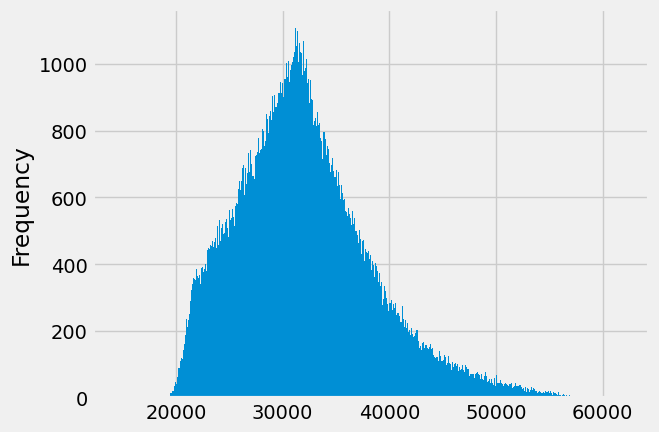

In [8]:
df['PJME_MW'].plot(kind='hist', bins=500)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

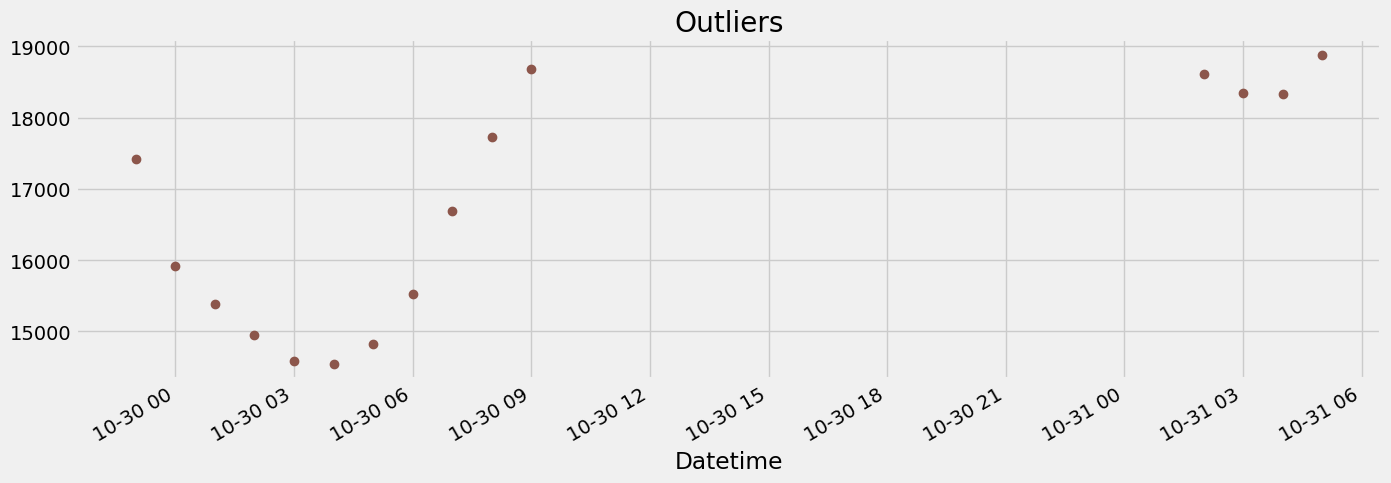

In [9]:
df.query('PJME_MW < 19_000')['PJME_MW'] \
    .plot(style='o',
          figsize=(15, 5),
          color=color_pal[5],
          title='Outliers')

In [10]:
df = df.query('PJME_MW > 19_000').copy()

# Train / Test Split

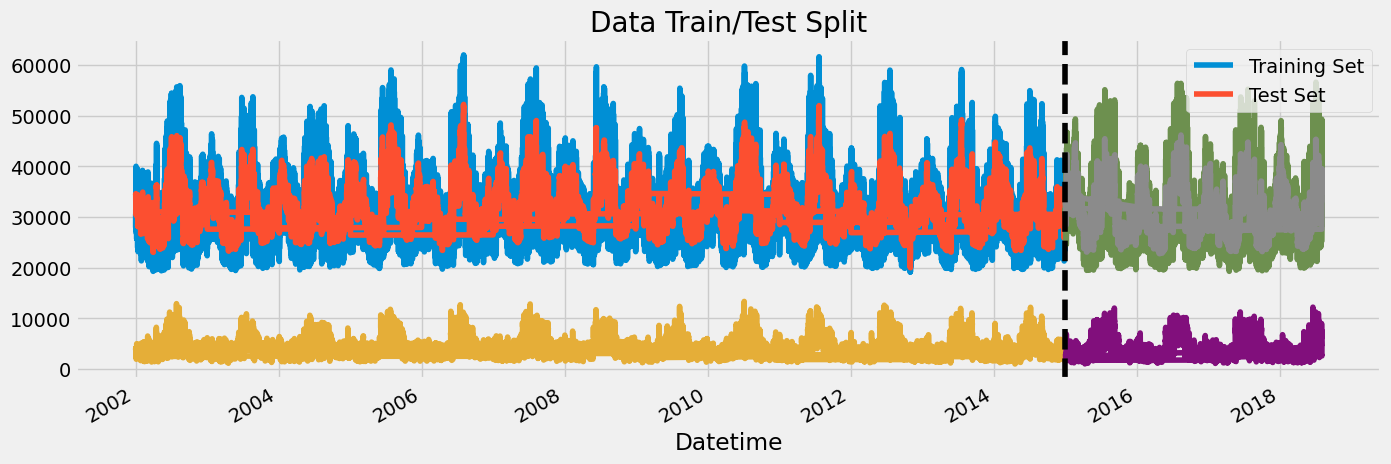

In [11]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

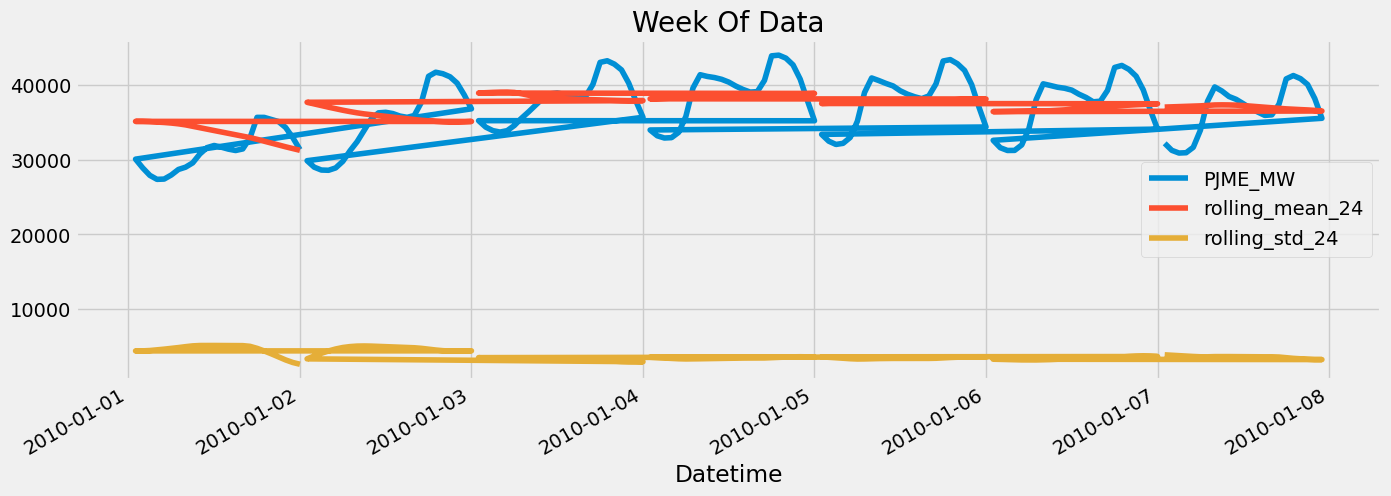

In [12]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# TimeSeries Cross Validation

In [13]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

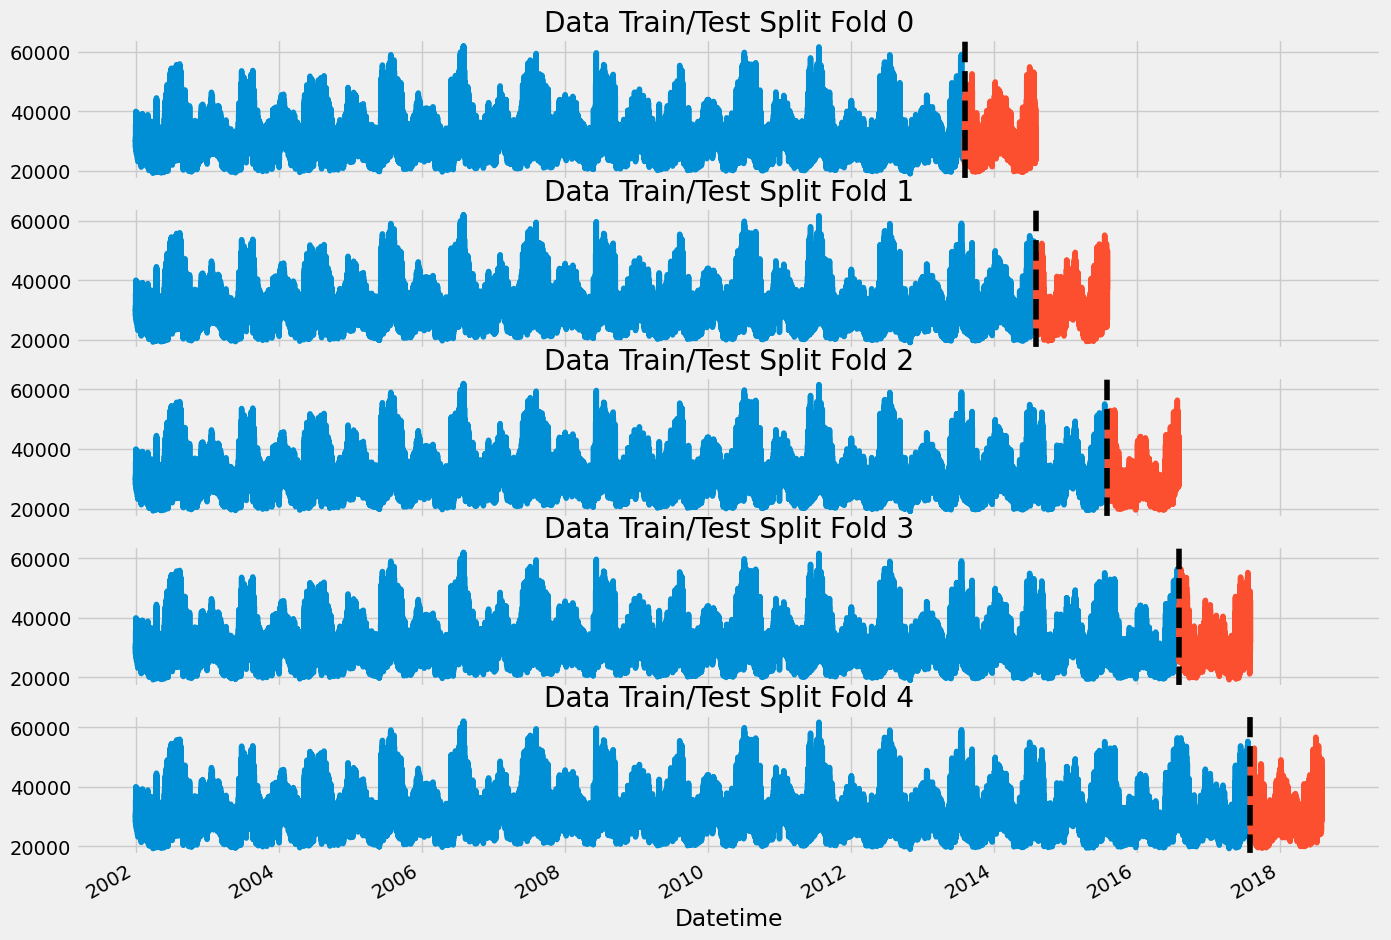

In [14]:
fig, axs = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

# Feature Creation

In [15]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    return df

df = create_features(df)

In [16]:
df.sample(5)

,PJME_MW,rolling_mean_24,rolling_std_24,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,is_weekend
Datetime,,,,,,,,,,,,
2006-04-03 02:00:00,21946.0,29475.708333,3835.820308,2,0,2,4,2006,93,3,14,0
2018-02-14 13:00:00,31153.0,30506.750000,2483.578716,13,2,1,2,2018,45,14,7,0
2003-11-19 23:00:00,28490.0,30027.583333,4294.497874,23,2,4,11,2003,323,19,47,0
2010-12-10 10:00:00,39748.0,34494.541667,2882.723772,10,4,4,12,2010,344,10,49,0
2006-10-13 20:00:00,32677.0,28853.791667,3546.633174,20,4,4,10,2006,286,13,41,0


# Lag Features

In [17]:
df['lag_24'] = df['PJME_MW'].shift(24)
df['lag_48'] = df['PJME_MW'].shift(48)
df['lag_168'] = df['PJME_MW'].shift(168)

df = df.dropna()

In [18]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [19]:
df = add_lags(df)

In [20]:
df.tail()

,PJME_MW,rolling_mean_24,rolling_std_24,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,is_weekend,lag_24,lag_48,lag_168,lag1,lag2,lag3
Datetime,,,,,,,,,,,,,,,,,,
2018-08-02 20:00:00,44057.0,37848.541667,7214.298134,20,3,3,8,2018,214,2,31,0,46912.0,40289.0,46337.0,42256.0,41485.0,38804.0
2018-08-02 21:00:00,43256.0,38348.958333,7152.674443,21,3,3,8,2018,214,2,31,0,45985.0,39938.0,44542.0,41210.0,40249.0,38748.0
2018-08-02 22:00:00,41552.0,38808.375000,6980.384192,22,3,3,8,2018,214,2,31,0,44094.0,38610.0,42638.0,39525.0,38698.0,37330.0
2018-08-02 23:00:00,38500.0,39195.500000,6675.858115,23,3,3,8,2018,214,2,31,0,40666.0,35950.0,39276.0,36490.0,35406.0,34552.0
2018-08-03 00:00:00,35486.0,39523.375000,6262.939842,0,4,3,8,2018,215,3,31,0,37158.0,33072.0,35742.0,33539.0,32094.0,31695.0


# Visualize our Feature / Target Relationship

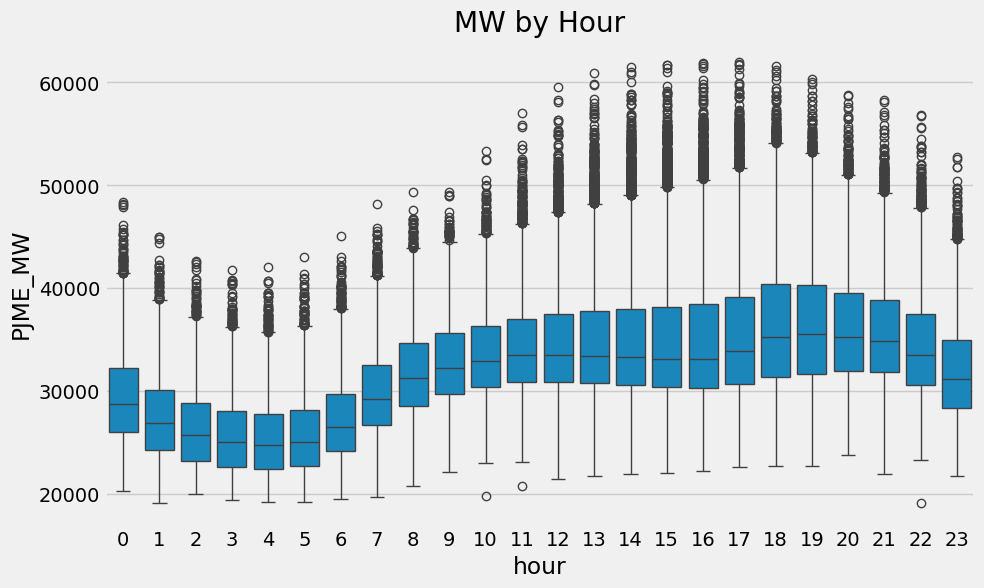

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

/tmp/ipykernel_16/1428223657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Greens')


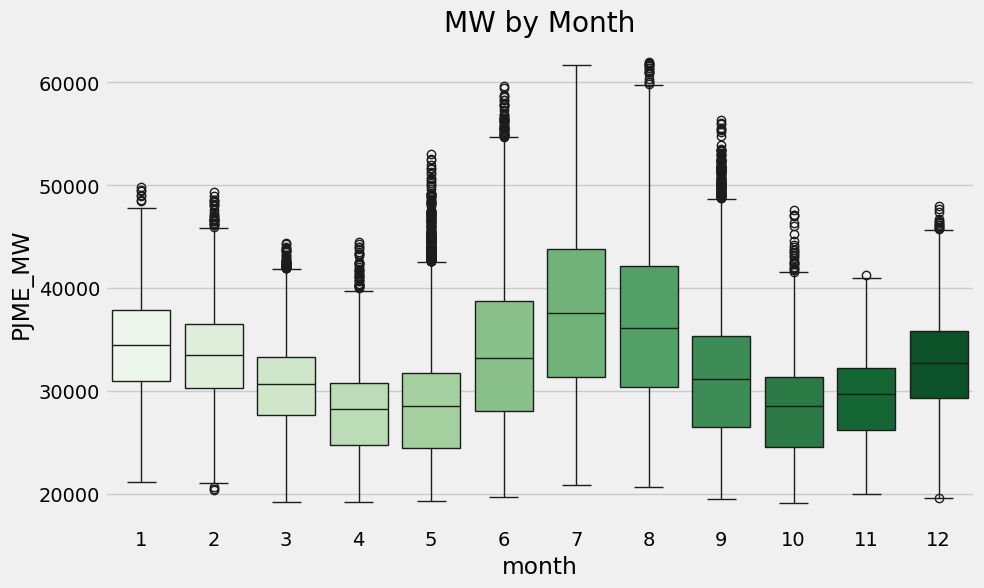

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Greens')
ax.set_title('MW by Month')
plt.show()

# Create our Model

In [23]:
fold = 0
preds = []
scores = []

for train_idx, val_idx in tss.split(df):
    
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    
    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year','lag1','lag2','lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]
    
    reg = xgb.XGBRegressor(n_estimators=1000,
                           early_stopping_rounds=50,
                           max_depth=3,
                           learning_rate=0.01)
#Early stopping is a technique used to stop training when the loss on validation dataset starts increase (in the case of minimizing the loss)

    reg.fit(X_train, 
            y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
    

[0]	validation_0-rmse:6461.09057	validation_1-rmse:6143.14259
[100]	validation_0-rmse:4369.60476	validation_1-rmse:4106.15099
[200]	validation_0-rmse:3813.15537	validation_1-rmse:3768.04938
[300]	validation_0-rmse:3539.62382	validation_1-rmse:3718.30471
[339]	validation_0-rmse:3467.35405	validation_1-rmse:3723.70225
[0]	validation_0-rmse:6436.24064	validation_1-rmse:6250.31512
[100]	validation_0-rmse:4373.19013	validation_1-rmse:4159.82426
[200]	validation_0-rmse:3835.88298	validation_1-rmse:3705.57191
[300]	validation_0-rmse:3576.55863	validation_1-rmse:3565.04953
[400]	validation_0-rmse:3431.74253	validation_1-rmse:3523.07660
[500]	validation_0-rmse:3349.26457	validation_1-rmse:3500.49290
[600]	validation_0-rmse:3299.31748	validation_1-rmse:3477.38324
[700]	validation_0-rmse:3262.28697	validation_1-rmse:3460.23973
[800]	validation_0-rmse:3223.76928	validation_1-rmse:3437.79007
[900]	validation_0-rmse:3196.78596	validation_1-rmse:3432.00324
[999]	validation_0-rmse:3168.29919	validatio

In [24]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3740.7690
Fold scores:[np.float64(3716.3233237551044), np.float64(3426.0332903358326), np.float64(3602.748405153967), np.float64(4100.329386305791), np.float64(3858.4103995189867)]


# Predict the Future

In [25]:
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year','lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
reg.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:6005.54377
[100]	validation_0-rmse:3909.85828
[200]	validation_0-rmse:4019.60577
[300]	validation_0-rmse:4063.52462
[400]	validation_0-rmse:4107.49438
[500]	validation_0-rmse:4126.97511
[600]	validation_0-rmse:4139.58967
[700]	validation_0-rmse:4152.16533
[800]	validation_0-rmse:4168.30594
[900]	validation_0-rmse:4178.00809
[999]	validation_0-rmse:4193.91013


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [27]:
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [28]:
future_w_features = df_and_future.query('isFuture').copy()

In [29]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

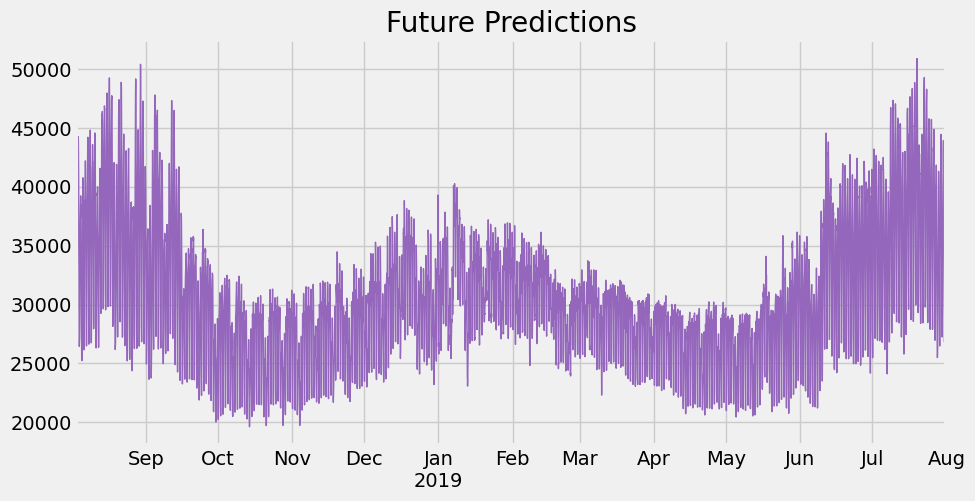

In [30]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

# Feature Importance

In [31]:
pred = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 4193.910128348411


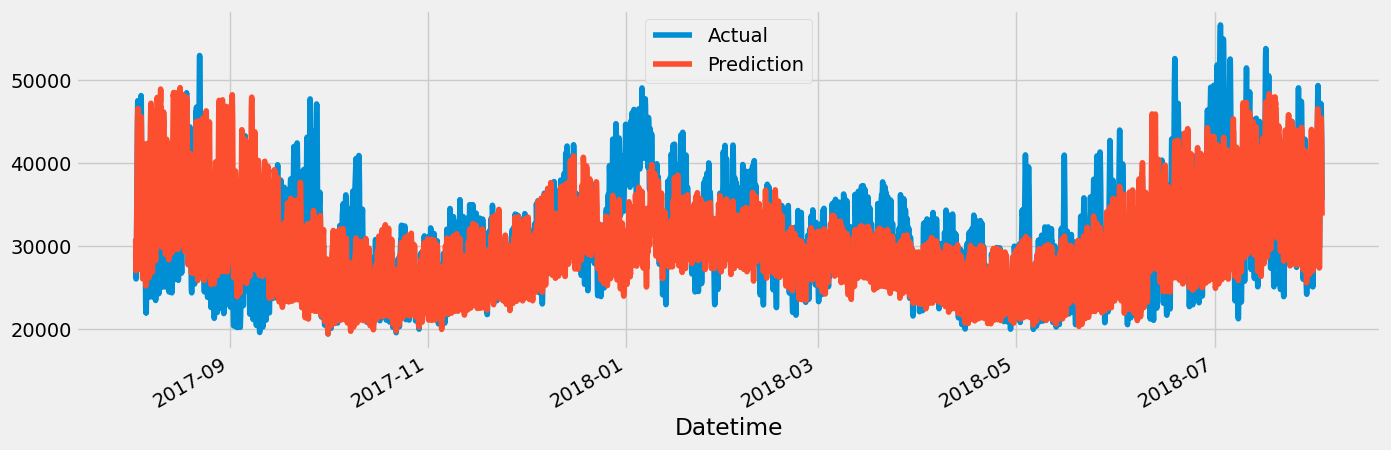

In [32]:
test['prediction'] = pred

ax = test[['PJME_MW']].plot(figsize=(15,5))
test['prediction'].plot(ax=ax)
plt.legend(['Actual','Prediction'])
plt.show()

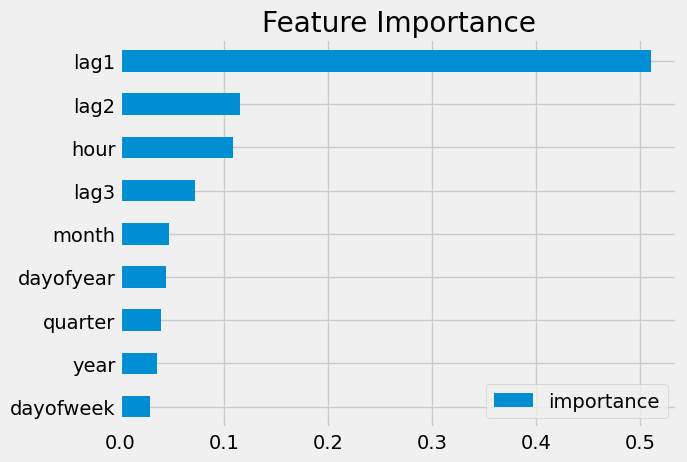

In [33]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

In [34]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 4193.91


In [35]:
print(test.columns)

Index(['PJME_MW', 'rolling_mean_24', 'rolling_std_24', 'hour', 'dayofweek',
       'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear',
       'is_weekend', 'lag_24', 'lag_48', 'lag_168', 'lag1', 'lag2', 'lag3',
       'prediction'],
      dtype='object')
